In [ ]:
# Step 1: Install required libraries
!pip install ultralytics opencv-python matplotlib deap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.3 MB/s eta 0:00:00


In [ ]:
# Step 2: Import libraries
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np
from deap import base, creator, tools, algorithms
import random


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Step 3: Upload 4 traffic images
print("Upload exactly 4 images (each showing a traffic signal):")
uploaded = files.upload()
image_paths = list(uploaded.keys())[:4]
if len(image_paths) != 4:
    raise ValueError("Please upload exactly 4 images.")


Upload exactly 4 images (each showing a traffic signal):


Saving S2.jpg to S2.jpg
Saving S3.jpg to S3.jpg
Saving S5.jpg to S5.jpg
Saving Signal1.jpg to Signal1.jpg


In [ ]:
 # Step 4: Load a more accurate YOLOv8 model (Open Images V7)
model = YOLO("yolov8s-oiv7.pt")  # pretrained on OpenImagesV7

# Define class IDs
vehicle_class_ids = [90, 73, 558, 342, 550]  # Car, Bus, Truck, Motorcycle, Train
ambulance_class_id = 6
van_class_id = 564  # fuzzy logic previously used

vehicle_counts = []
ambulance_present = []
images = []



100%|██████████| 21.9M/21.9M [00:00<00:00, 62.1MB/s]


In [ ]:
# Step 1: Install required libraries
!pip install ultralytics opencv-python matplotlib deap --quiet

# Step 2: Import libraries
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np
from deap import base, creator, tools, algorithms
import random

# Step 3: Upload 4 traffic images
print("Upload exactly 4 images (each showing a traffic signal):")
uploaded = files.upload()
image_paths = list(uploaded.keys())[:4]
if len(image_paths) != 4:
    raise ValueError("Please upload exactly 4 images.")

# Step 4: Load a more accurate YOLOv8 model (Open Images V7)
model = YOLO("yolov8s-oiv7.pt")  # pretrained on OpenImagesV7

# Step 5: Detect vehicles + ambulances (with fuzzy van detection)
vehicle_class_ids = [90, 73, 558, 342, 550]  # Car, Bus, Truck, Motorcycle, Train
ambulance_class_id = 6  # Ambulance
van_class_id = 564      # Van

vehicle_counts = []
ambulance_present = []
images = []

for img_path in image_paths:
    print(f"\nAnalyzing Image: {img_path}")
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = model(img_rgb, imgsz=640)
    res = results[0]
    boxes = res.boxes

    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    cls_ids = boxes.cls.cpu().numpy().astype(int)

    vehicle_count = 0
    ambulance_flag = False

    for (x1, y1, x2, y2), conf, cls in zip(xyxy, confs, cls_ids):
        label = model.names[cls].lower()
        print(f"  Detected: {label} (ID {cls}) with confidence {conf:.2f}")
        if conf < 0.25:
            continue

        is_ambulance = (
            cls == ambulance_class_id or
            'ambulance' in label or
            (cls == van_class_id and conf > 0.7)
        )

        if is_ambulance:
            ambulance_flag = True
            cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 3)
            cv2.putText(img_rgb, "AMBULANCE (fuzzy)" if cls == van_class_id else "AMBULANCE",
                        (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        elif cls in vehicle_class_ids:
            vehicle_count += 1
            cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(img_rgb, label.capitalize(), (int(x1), int(y1) - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    vehicle_counts.append(vehicle_count)  #Update array
    ambulance_present.append(ambulance_flag)

    # Annotate vehicle count
    cv2.putText(img_rgb, f"Vehicles: {vehicle_count}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                (255, 0, 0) if ambulance_flag else (255, 255, 0), 2)

    images.append(img_rgb)

# Step 6: Genetic Algorithm setup
CYCLE_TIME, MIN_GREEN, MAX_GREEN, N_SIGNALS = 120, 10, 60, 4

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(ind):
    total = sum(ind)
    if total == 0:
        return -float('inf'),
    norm = [t * CYCLE_TIME / total for t in ind]
    if any(t < MIN_GREEN or t > MAX_GREEN for t in norm):
        return -float('inf'),
    total_vehicles = sum(vehicle_counts)
    if total_vehicles == 0:
        return -float('inf'),
    ideal = [v / total_vehicles for v in vehicle_counts]
    actual = [t / CYCLE_TIME for t in norm]
    dev = sum((i - a) ** 2 for i, a in zip(ideal, actual))
    return -dev,

def init_individual():
    vals = [random.uniform(MIN_GREEN, MAX_GREEN) for _ in range(N_SIGNALS)]
    total = sum(vals)
    return creator.Individual([v * CYCLE_TIME / total for v in vals])

toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, init_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=50)
for _ in range(100):
    offspring = algorithms.varAnd(pop, toolbox, cxpb=0.7, mutpb=0.3)
    fits = list(map(toolbox.evaluate, offspring))
    for ind, fit in zip(offspring, fits):
        ind.fitness.values = fit
    pop = toolbox.select(offspring, k=len(pop))

best = tools.selBest(pop, k=1)[0]
green_times = [round(t * CYCLE_TIME / sum(best), 1) for t in best]

# Step 7: Prioritize ambulance signals
for i in range(N_SIGNALS):
    if ambulance_present[i]:
        green_times[i] = MAX_GREEN

# Normalize if total time exceeds cycle
total_time = sum(green_times)
if total_time > CYCLE_TIME:
    extra = total_time - CYCLE_TIME
    other_idxs = [i for i in range(N_SIGNALS) if not ambulance_present[i]]
    total_other = sum(green_times[i] for i in other_idxs)
    for i in other_idxs:
        green_times[i] -= extra * (green_times[i] / total_other)

# Step 8: Show annotated images
plt.figure(figsize=(12, 8))
for i, (img, vc, gt, amb) in enumerate(zip(images, vehicle_counts, green_times, ambulance_present)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    title = f"Signal {i+1}: {vc} Vehicles\nGreen Time: {round(gt)}s"
    if amb:
        title += " 🚑 PRIORITY"
    plt.title(title)
plt.tight_layout()
plt.show()

# Step 9: Print results
print("\nVehicle Counts and Green Times (w/ Ambulance Priority):")
for i in range(4):
    priority = " 🚑" if ambulance_present[i] else ""
    print(f"Signal {i+1}: {vehicle_counts[i]} vehicles → Green Time: {round(green_times[i])}s{priority}")

# Step 10: Bar chart of green times
plt.figure(figsize=(7, 5))
labels = [f"S{i+1}" for i in range(4)]
colors = ['#4CAF50', '#2196F3', '#FFC107', '#FF5722']
plt.bar(labels, green_times, color=colors, edgecolor='black')
plt.ylabel("Green Time (seconds)")
plt.title("Optimized Signal Green Times")
for i, v in enumerate(green_times):
    plt.text(i, v + 1, f"{round(v)}s", ha='center', fontweight='bold')
plt.ylim(0, MAX_GREEN + 10)
plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━ 308.7/664.8 MB 99.9 MB/s eta 0:00:04
ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
# Step 5: Detection
for img_path in image_paths:
    print(f"\nAnalyzing Image: {img_path}")
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = model(img_rgb, imgsz=640)
    res = results[0]
    boxes = res.boxes

    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    cls_ids = boxes.cls.cpu().numpy().astype(int)

    vehicle_count = 0
    ambulance_flag = False

    for (x1, y1, x2, y2), conf, cls in zip(xyxy, confs, cls_ids):
        label = model.names[cls].lower()
        print(f"  Detected: {label} (ID {cls}) with confidence {conf:.2f}")

        if conf < 0.2:
            continue  # Slightly lowered threshold to catch motorcycles

        is_ambulance = (
            cls == ambulance_class_id or
            'ambulance' in label or
            (cls == van_class_id and conf > 0.7)
        )

        if is_ambulance:
            ambulance_flag = True
            vehicle_count += 1  # Count ambulance as a vehicle
            cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 3)
            cv2.putText(img_rgb, "AMBULANCE",
                        (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        elif cls in vehicle_class_ids:
            vehicle_count += 1
            cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(img_rgb, label.capitalize(), (int(x1), int(y1) - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    vehicle_counts.append(vehicle_count)
    ambulance_present.append(ambulance_flag)

    # Annotate vehicle count
    cv2.putText(img_rgb, f"Vehicles: {vehicle_count}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1,
                (255, 0, 0) if ambulance_flag else (255, 255, 0), 2)

    images.append(img_rgb)




Analyzing Image: S2.jpg

0: 480x640 2 Buss, 1 Car, 42.3ms
Speed: 12.0ms preprocess, 42.3ms inference, 353.1ms postprocess per image at shape (1, 3, 480, 640)
  Detected: car (ID 90) with confidence 0.67
  Detected: bus (ID 73) with confidence 0.53
  Detected: bus (ID 73) with confidence 0.44

Analyzing Image: S3.jpg

0: 480x640 8 Cars, 1 Van, 14.4ms
Speed: 4.8ms preprocess, 14.4ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)
  Detected: car (ID 90) with confidence 0.74
  Detected: car (ID 90) with confidence 0.72
  Detected: car (ID 90) with confidence 0.57
  Detected: car (ID 90) with confidence 0.57
  Detected: car (ID 90) with confidence 0.57
  Detected: car (ID 90) with confidence 0.55
  Detected: car (ID 90) with confidence 0.48
  Detected: car (ID 90) with confidence 0.41
  Detected: van (ID 564) with confidence 0.28

Analyzing Image: S5.jpg

0: 640x640 2 Cars, 1 Van, 18.3ms
Speed: 6.9ms preprocess, 18.3ms inference, 1.4ms postprocess per image at shape (1, 3

In [ ]:
# Step 6: Genetic Algorithm setup
CYCLE_TIME, MIN_GREEN, MAX_GREEN, N_SIGNALS = 120, 10, 60, 4

#Define the structure of your Genetic Algorithm

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def evaluate(ind):
    total = sum(ind)
    if total == 0:
        return -float('inf'),


    norm = [t * CYCLE_TIME / total for t in ind] #Ensure traffic signal time sum = 120

    #Ignore the cases where minimum and maximum duration rule is distrub
    if any(t < MIN_GREEN or t > MAX_GREEN for t in norm):
        return -float('inf'),

    #Measure how well the green times match the traffic at each signal.
    total_vehicles = sum(vehicle_counts)

    if total_vehicles == 0:
        return -float('inf'),

    ideal = [v / total_vehicles for v in vehicle_counts]
    actual = [t / CYCLE_TIME for t in norm]
    dev = sum((i - a) ** 2 for i, a in zip(ideal, actual))
    return -dev,

def init_individual():
    vals = [random.uniform(MIN_GREEN, MAX_GREEN) for _ in range(N_SIGNALS)]
    total = sum(vals)
    return creator.Individual([v * CYCLE_TIME / total for v in vals])

toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, init_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

pop = toolbox.population(n=50)
for _ in range(100):
    offspring = algorithms.varAnd(pop, toolbox, cxpb=0.7, mutpb=0.3)
    fits = list(map(toolbox.evaluate, offspring))
    for ind, fit in zip(offspring, fits):
        ind.fitness.values = fit
    pop = toolbox.select(offspring, k=len(pop))

best = tools.selBest(pop, k=1)[0]
green_times = [round(t * CYCLE_TIME / sum(best), 1) for t in best]



In [ ]:
# Step 7: Prioritize ambulance signals
for i in range(N_SIGNALS):
    if ambulance_present[i]:
        green_times[i] = MAX_GREEN

# Normalize if total time exceeds cycle
total_time = sum(green_times)
if total_time > CYCLE_TIME:
    extra = total_time - CYCLE_TIME
    other_idxs = [i for i in range(N_SIGNALS) if not ambulance_present[i]]
    total_other = sum(green_times[i] for i in other_idxs)
    for i in other_idxs:
        green_times[i] -= extra * (green_times[i] / total_other)



/tmp/ipython-input-8-3644802626.py:11: UserWarning: Glyph 128657 (\N{AMBULANCE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128657 (\N{AMBULANCE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


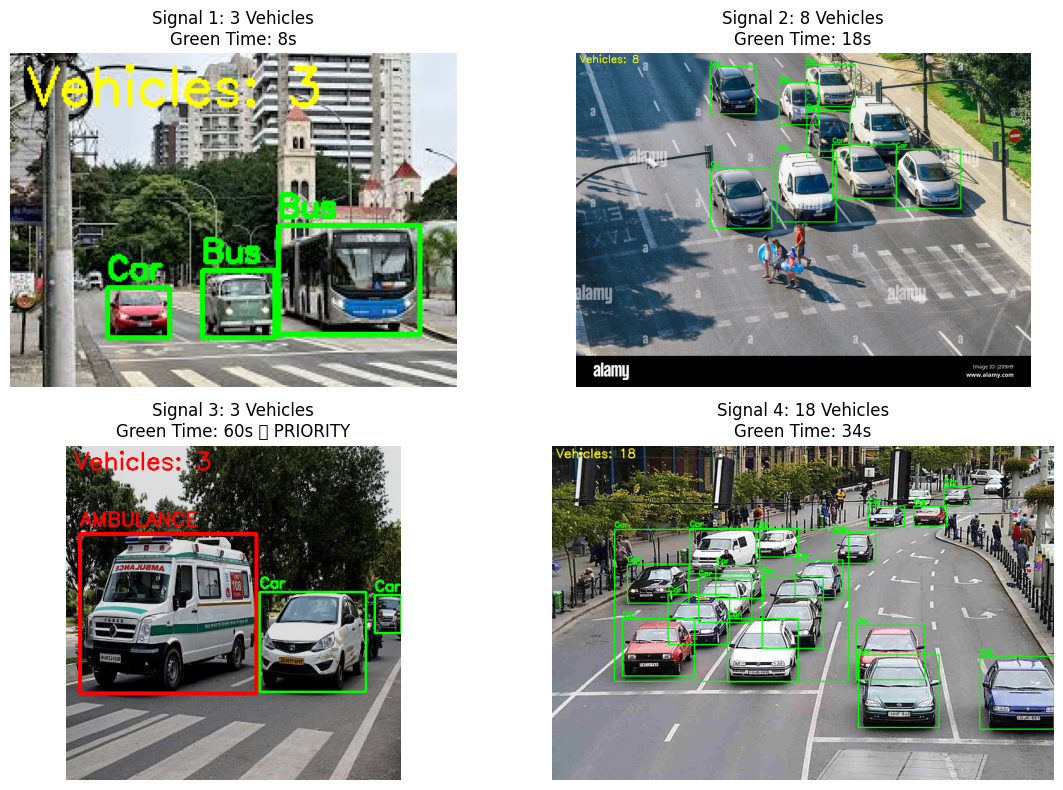

In [ ]:
# Step 8: Show annotated images
plt.figure(figsize=(12, 8))
for i, (img, vc, gt, amb) in enumerate(zip(images, vehicle_counts, green_times, ambulance_present)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    title = f"Signal {i+1}: {vc} Vehicles\nGreen Time: {round(gt)}s"
    if amb:
        title += " 🚑 PRIORITY"
    plt.title(title)
plt.tight_layout()
plt.show()



In [ ]:
# Step 9: Print results
print("\nVehicle Counts and Green Times (w/ Ambulance Priority):")
for i in range(4):
    priority = " 🚑" if ambulance_present[i] else ""
    print(f"Signal {i+1}: {vehicle_counts[i]} vehicles → Green Time: {round(green_times[i])}s{priority}")




Vehicle Counts and Green Times (w/ Ambulance Priority):
Signal 1: 3 vehicles → Green Time: 8s
Signal 2: 8 vehicles → Green Time: 18s
Signal 3: 3 vehicles → Green Time: 60s 🚑
Signal 4: 18 vehicles → Green Time: 34s


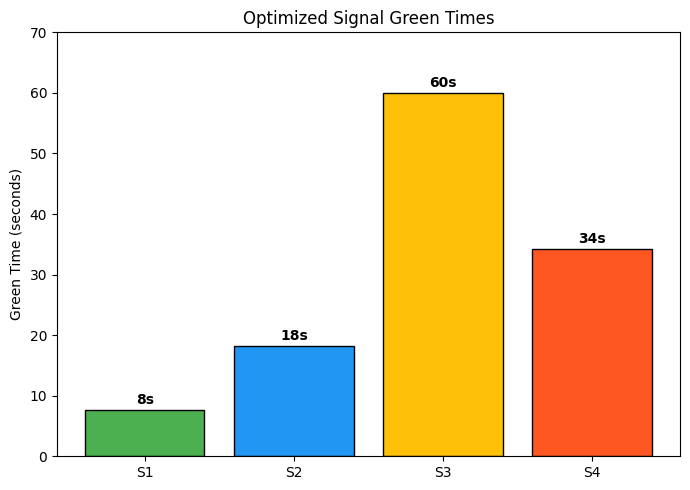

In [ ]:
# Step 10: Bar chart of green times
plt.figure(figsize=(7, 5))
labels = [f"S{i+1}" for i in range(4)]
colors = ['#4CAF50', '#2196F3', '#FFC107', '#FF5722']
plt.bar(labels, green_times, color=colors, edgecolor='black')
plt.ylabel("Green Time (seconds)")
plt.title("Optimized Signal Green Times")
for i, v in enumerate(green_times):
    plt.text(i, v + 1, f"{round(v)}s", ha='center', fontweight='bold')
plt.ylim(0, MAX_GREEN + 10)
plt.tight_layout()
plt.show()
